<a href="https://colab.research.google.com/github/antohachekhov/Credit-Card-Fraud/blob/main/eda_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

**Цель проекта**: построить модель для выявления мошеннических транзакций по кредитным картам.


# Данные
Датасет взят с платформы Kaggle ([ссылка на датасет](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)). Этот датасет получен неназванным институтом.

Набор данных содержит 1 000 000 записей без пропусков по 8 признакам.

Данные сильно несбалансированы - мошеннические транзакции составляют <1%.

In [1]:
# Чтение данных
from google.colab import drive
import pandas as pd

drive.mount('/content/drive') # подключение облачного хранилища Google Drive
pathToDataset = "/content/drive/MyDrive/card_transdata.csv"
dataset = pd.read_csv(pathToDataset)

Mounted at /content/drive


## Описание признаков

*   distance_from_home - дистанция от дома до места совершения транзакции
*   distance_from_last_transaction - дистанция от прошлого места совершения транзакции
*   ratio_to_median_purchase_price - отношение цены транзакции к медианной цене транзакций, совершенных ранее
*   repeat_retailer - была ли транзакция совершена с тем же продавцом ранее (0 - нет, 1 - да)
*   used_chip - была ли транзакция совершена с помощью чипа, т.е. кредитной карты (0 - нет, 1 - да)
*   used_pin_number - была ли транзакция совершена с введением PIN-кода (0 - нет, 1 - да)
*   online_order - является ли транзакция онлайн-покупкой (0 - нет, 1 - да)
*   fraud - является ли транзакция мошеннической (0 - нет, 1 - да)

In [3]:
dataset.iloc[:, 3:] = dataset.iloc[:, 3:].astype('category') # приведение признаков к категориальному типу
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   distance_from_home              1000000 non-null  float64 
 1   distance_from_last_transaction  1000000 non-null  float64 
 2   ratio_to_median_purchase_price  1000000 non-null  float64 
 3   repeat_retailer                 1000000 non-null  category
 4   used_chip                       1000000 non-null  category
 5   used_pin_number                 1000000 non-null  category
 6   online_order                    1000000 non-null  category
 7   fraud                           1000000 non-null  category
dtypes: category(5), float64(3)
memory usage: 27.7 MB


Признаки `distance_from_home`, `distance_from_last_transaction и `ratio_to_median_purchase_price` являются количественным признакими - вещественные неотрицаительные числа.

Признаки `repeat_retailer`, `used_chip`, `used_pin_number`, `online_order` и `fraud` - категориальные признаки по дихотомической шкале (0 или 1).

**Целевой признак - `fraud`.**

In [4]:
# Получим списки названий количественных и категориальных признаков
numeric_features = dataset.select_dtypes(include=['number']).columns.tolist()
categorical_features = dataset.select_dtypes(include=['category']).columns.tolist()

# EDA

## Статистические характеристики

**Статистические характеристики для числовых признаков**

In [5]:
dataset[numeric_features].describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
count,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182
std,65.390784,25.843093,2.799589
min,0.004874,0.000118,0.004399
25%,3.878008,0.296671,0.475673
50%,9.967760,0.998650,0.997717
75%,25.743985,3.355748,2.096370
max,10632.723672,11851.104565,267.802942


В 75% случаев люди совершают покупки недалеко - в не более чем 26 км от дома и не более чем 4 км от места прошлой покупки.

Обычно люди совершают покупки на сумму, примерно равную медиане всех их покупок. В 75% случаев сумма покупки не превышает примерно двойное значение медианы их покупок.

Можно заметить, что у всех числовых признаков среднее больше медианы (более того, у признаков `distance_from_home` и `distance_from_last_transaction` среднее больше верхнего квартиля). А также максимальные значения во много раз превышают верхний квартиль.

Следовательно, можно сделать следующие выводы:

- большинство транзакций сосредоточено в области малых значений признаков, тогда как крупные значения являются редкими и могут соответствовать аномальным (в том числе мошенническим) операциям;
- распределения признаков имеют тяжелые правые хвосты.

Из-за огромного размаха значений признаков, возможно потребуется лог-преобразование признаков. При подборе модели обучения лучше выбирать модель, устойчивую к выбросам.



**Статистические характеристики для категориальных данных**

In [6]:
dataset[categorical_features].describe()

,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.0,1000000.0,1000000.0,1000000.0,1000000.0
unique,2.0,2.0,2.0,2.0,2.0
top,1.0,0.0,0.0,1.0,0.0
freq,881536.0,649601.0,899392.0,650552.0,912597.0


Покупатели чаще всего совершают транзакции у знакомого продавца, без использования чип-карт, без ввода пин-кода, в онлайн-магазинах.

Доля мошеннических транзакций составляет около 8.7%. Следовательно, в данных сильный дисбаланс классов.

## Диаграммы размаха

Определение границ выбросов для количественных признаков по методу Тьюки и подсчёт доли выбросов

In [7]:
Q1 = dataset[numeric_features].quantile(0.25)
Q3 = dataset[numeric_features].quantile(0.75)
IQR = Q3 - Q1

bounds = pd.DataFrame({
    "lower_bound": Q1 - 1.5 * IQR,
    "upper_bound": Q3 + 1.5 * IQR
})

outlier_ratio = []
for col in numeric_features:
    lower = bounds.loc[col, "lower_bound"]
    upper = bounds.loc[col, "upper_bound"]
    outliers = ((dataset[col] < lower) | (dataset[col] > upper)).mean()
    outlier_ratio.append(outliers)
bounds["outlier_ratio"] = outlier_ratio
bounds

,lower_bound,upper_bound,outlier_ratio
distance_from_home,-28.920958,58.542951,0.103631
distance_from_last_transaction,-4.291945,7.944363,0.124367
ratio_to_median_purchase_price,-1.955372,4.527416,0.084386


В среднем выбросы составляют 10% выборки, что является не малой частью.

Построим диаграммы размаха.

С логарифмической шкалой:

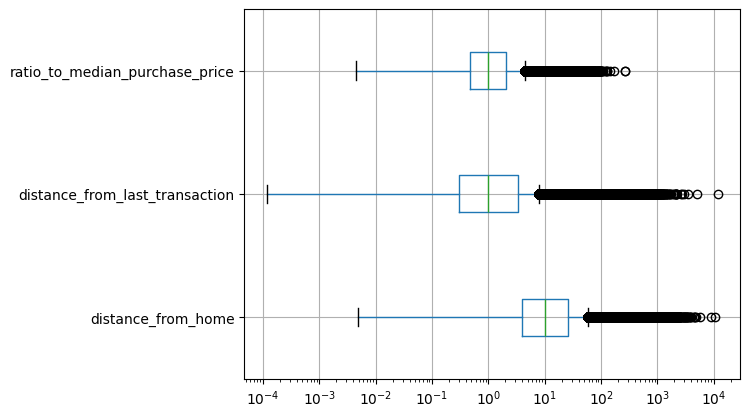

In [8]:
import numpy as np
import matplotlib.pyplot as plt

box = dataset[numeric_features].boxplot(vert=False)
box.set_xscale('log')
plt.show()

С обычной шкалой, обрезав выбросы

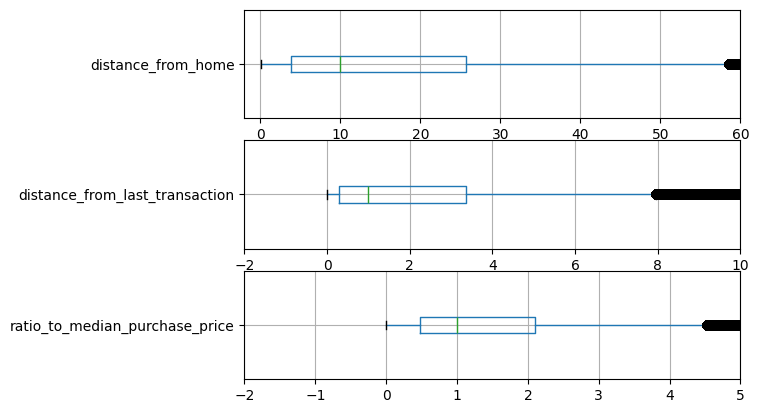

In [9]:
fig, axes = plt.subplots(3, 1)
boxes = [dataset.boxplot(numeric_features[i], vert=False, ax=axes[i]) for i in range(3)]

round_to_5 = lambda x: round(x / 5) * 5
for col, b in zip(numeric_features, boxes):
  b.set_xlim(left=-2, right=round_to_5(bounds.loc[col, "upper_bound"]))
plt.show()

Количественные признаки имеют скошенные вправо распределения с длинными правыми хвостами, что указывает на наличие экстремальных значений. Наблюдается, что медианы распределений более смещены влево, т.е. можно сделать вывод, что "типичные" транзакции имеют относительно небольшие значения признаков.

## Парные диаграммы

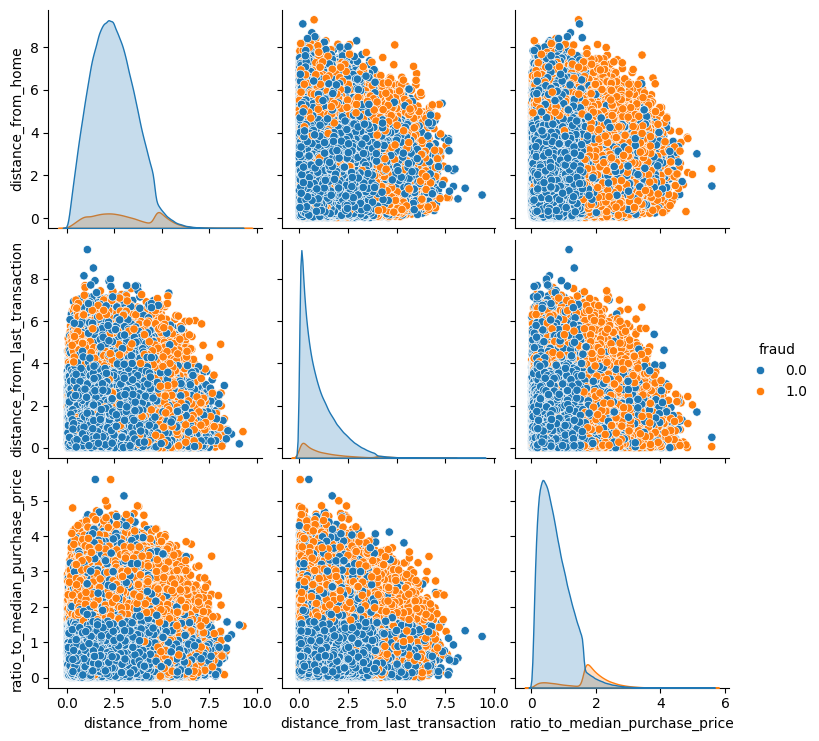

In [72]:
import seaborn as sns

# Сделаем копию датасета, содержащую значения числовых признаков после лог-преобразования
dataset_log1p = dataset[numeric_features + ['fraud']].copy()
for col in numeric_features:
    dataset_log1p[col] = np.log1p(dataset[col]) # сделаем лог-преобразование log(1+x),
                                                # чтобы сохранить строгую положительность признаков
sns.pairplot(dataset_log1p, hue="fraud")

Классы не полностью разделимы.

По всем диаграммам видно, что мошеннические транзакции чаще всего соответствуют большим значениям признаков. При небольших значениях признаков парные диаграммы содержат почти только синие точки (не мошенническая транзакция).

Особенно заметно, что существует некоторая граница признака `ratio_to_median_purchase_price`, при которой частота мошеннических транзакций резко увеличивается. Это также видно по графику распределения `fraud` для этого признака - при резком уменьшении `fraud=0` происходит резкий скачок `fraud=1`.

Ещё наблюдение - нет таких данных, содержащие огромные значения любой пары признаков одновременно. Все диаграммы похожи на треугольники -  при увеличении одного признака другой уменьшается. Следовательно, можно подозревать, что существует зависимость между признаками.

## Графики квантиль-квантиль

Проверим подчиняются ли признаки ряду распределений.

1. Нормальное распределение

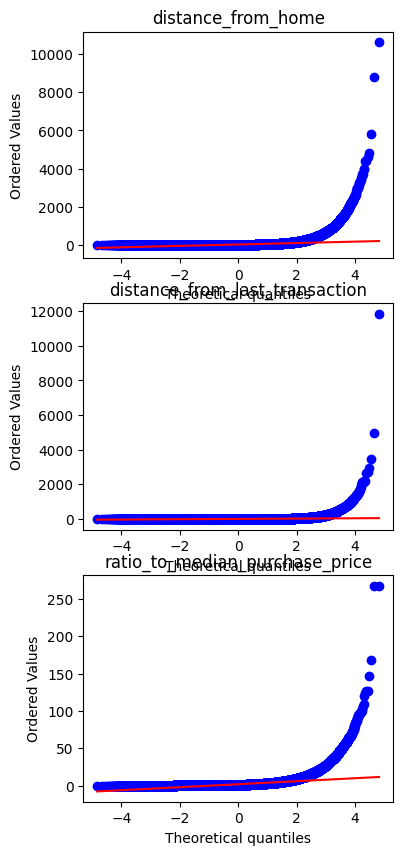

In [34]:
import scipy.stats as stats

fig, axis = plt.subplots(3, 1, figsize=(4, 10))
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Из-за тяжелых правых хвостов нельзя утверждать, что распределения признаков являются нормальными

2. Нормальному распределению после преобразования $\log(x+1)$

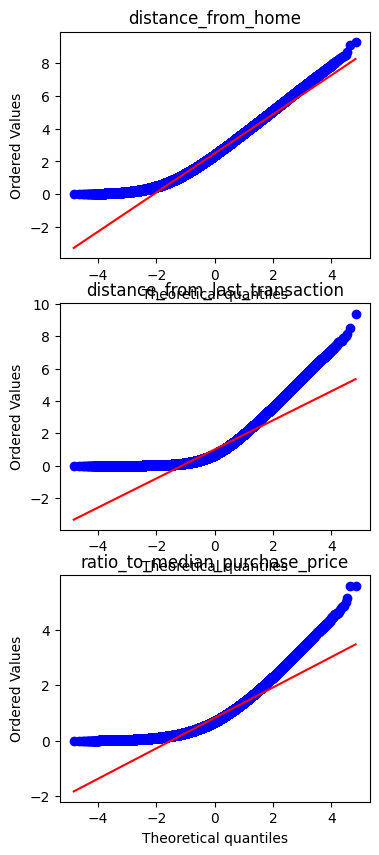

In [35]:
fig, axis = plt.subplots(3, 1, figsize=(4, 10))
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset_log1p[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Как видно, после преобразования $\log(1+x)$ признаки не подчиняются нормальному распределению.

3. Логнормальному распределению

Как известно, если $Y=\ln(X)\sim\mathcal{N}(\mu,\sigma)$, то $X\sim\text{LogNorm}(\mu,\sigma)$. Чтобы проверить признаки на логнормальность, нужно сделать лог-преобразование вида $\log(x)$

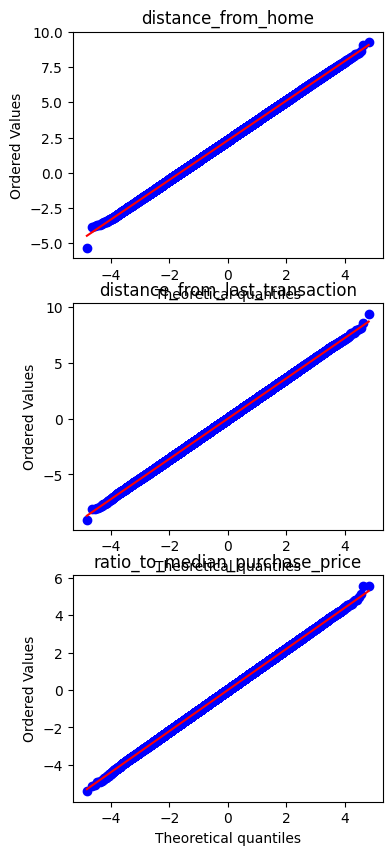

In [36]:
# сделаем лог-преобразование вида log(x) для числовых признаков
dataset_log = dataset[numeric_features + ['fraud']].copy()
for col in numeric_features:
    dataset_log[col] = np.log(dataset[col])

fig, axis = plt.subplots(3, 1, figsize=(4, 10))
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset_log[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Как видно, график квантиль-квантиль практически имеет форму прямой кривой. Следовательно, можно утвержать, что распределение всех числовых признаков очень близко к логнормальному распределению.

Посчитаем оценки параметров распределений празнаков:

In [38]:
for feature in numeric_features:
  print(feature)
  print(f'mean: {dataset_log[feature].mean()}\tstd: {dataset_log[feature].std()}\n')

distance_from_home
mean: 2.3005518671829286	std: 1.4016574094446639

distance_from_last_transaction
mean: -0.002715988136237382	std: 1.7993864607684393

ratio_to_median_purchase_price
mean: -0.0018716709892106186	std: 1.098468215466887



## Точечные графики

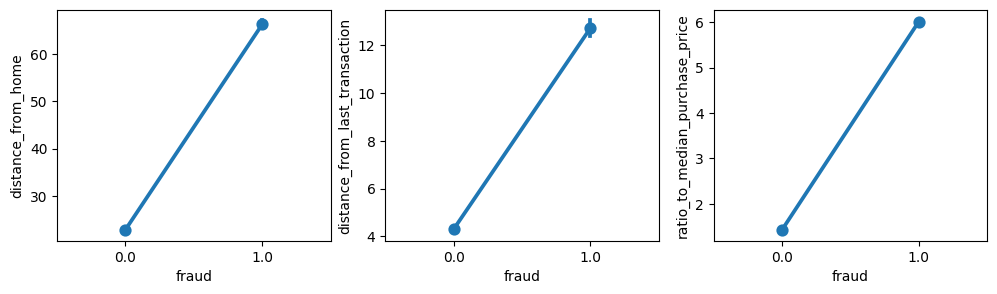

In [42]:
fig, axis = plt.subplots(1, 3, figsize=(12, 3))
for i, feature in enumerate(numeric_features):
  sns.pointplot(x="fraud", y=feature, data=dataset, ax=axis[i])

plt.show()

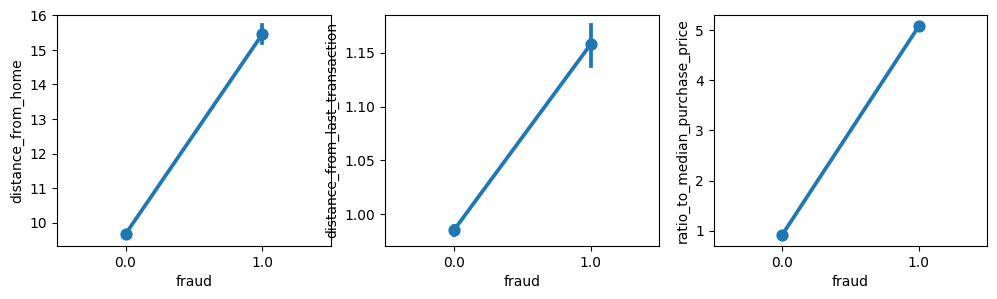

In [44]:
fig, axis = plt.subplots(1, 3, figsize=(12, 3))
for i, feature in enumerate(numeric_features):
  sns.pointplot(x="fraud", y=feature, data=dataset, ax=axis[i], estimator=np.median)
plt.show()

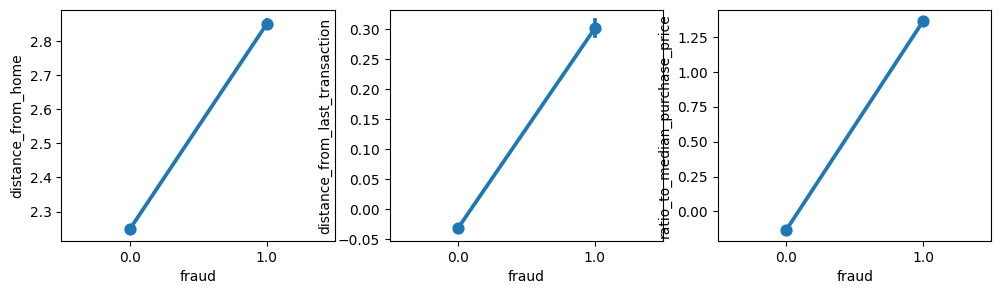

In [43]:
fig, axis = plt.subplots(1, 3, figsize=(12, 3))
for i, feature in enumerate(numeric_features):
  sns.pointplot(x="fraud", y=np.log(dataset[feature]), data=dataset, ax=axis[i])

plt.show()

<Figure size 432x288 with 0 Axes>

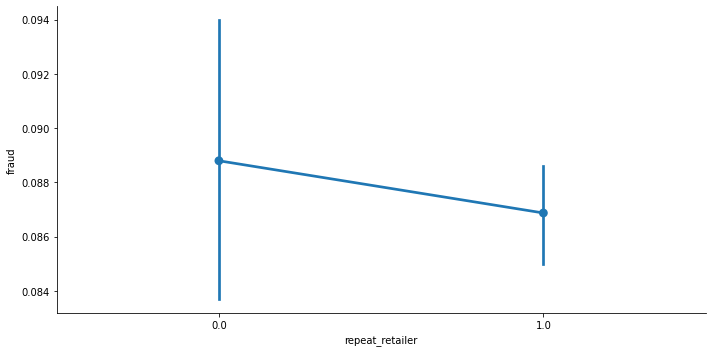

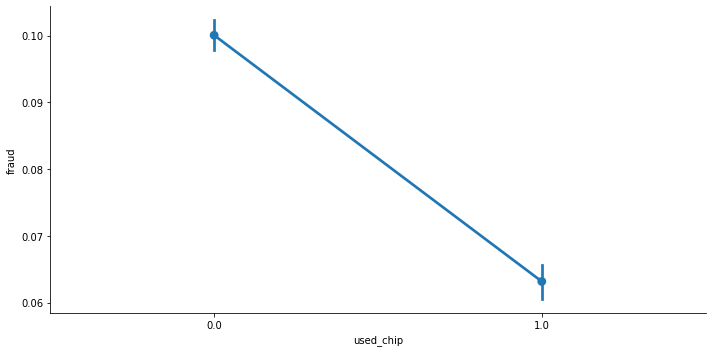

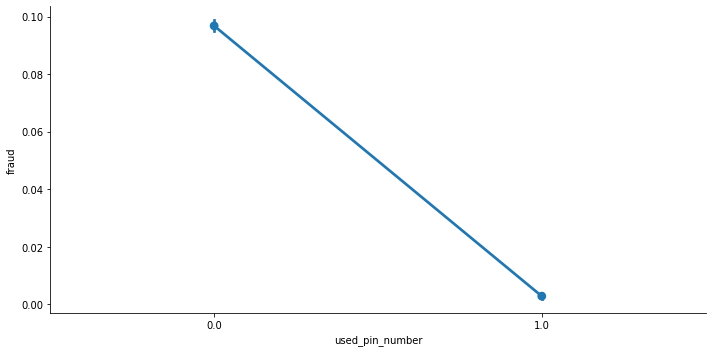

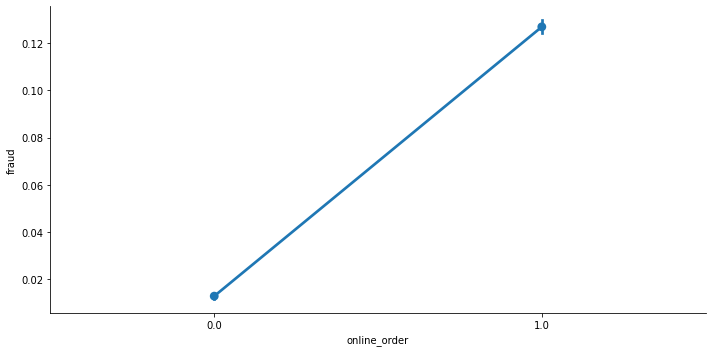

In [ ]:
#@title Point-plot

import seaborn as sns
for i, col in enumerate(['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']):
  plt.figure(i)
  sns.catplot(x=col, y='fraud', data=dataset, kind='point', aspect=2,)

In [ ]:
#@title Pivot Table

dataset.pivot_table('fraud', index='repeat_retailer', columns='online_order', aggfunc='count')

online_order,0.0,1.0
repeat_retailer,,
0.0,4173,7618
1.0,30761,57448


In [ ]:
dataset.pivot_table('fraud', index='repeat_retailer', columns='used_chip', aggfunc='count')

used_chip,0.0,1.0
repeat_retailer,,
0.0,7611,4180
1.0,57283,30926


In [ ]:
dataset.pivot_table('fraud', index='repeat_retailer', columns='used_pin_number', aggfunc='count')

used_pin_number,0.0,1.0
repeat_retailer,,
0.0,10551,1240
1.0,79124,9085


In [ ]:
dataset.pivot_table('fraud', index='used_chip', columns='online_order', aggfunc='count')

online_order,0.0,1.0
used_chip,,
0.0,22633,42261
1.0,12301,22805


In [ ]:
dataset.pivot_table('fraud', index='used_chip', columns='used_pin_number', aggfunc='count')

used_pin_number,0.0,1.0
used_chip,,
0.0,58193,6701
1.0,31482,3624


In [ ]:
dataset.pivot_table('fraud', index='online_order', columns='used_pin_number', aggfunc='count')

used_pin_number,0.0,1.0
online_order,,
0.0,31336,3598
1.0,58339,6727


In [ ]:
#@title Corr

dataset.corr(method='pearson', min_periods=1)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
distance_from_home,1.000000,-0.002562,-0.000656
distance_from_last_transaction,-0.002562,1.000000,0.000531
ratio_to_median_purchase_price,-0.000656,0.000531,1.000000


In [ ]:
(dataset.iloc[:, 3:]).corr(dataset.iloc[:, 3:])

NameError: ignored

In [ ]:
def tetrachoric_correlation(pivot_table):
    a = pivot_table[0][0]
    b = pivot_table[1][0]
    c = pivot_table[0][1]
    d = pivot_table[1][1]
    tetrachoric_correlation = np.cos(np.pi/(1+np.sqrt((a * d) / b / c)))
    return tetrachoric_correlation

In [ ]:
categorical_columns = dataset.loc[:, ((dataset.dtypes == 'category') & (dataset.columns != 'fraud'))].columns
contingency_tables = []
for column in categorical_columns:
    contingency_table = pd.crosstab(dataset[column], dataset['fraud'])
    contingency_tables.append(contingency_table)
    print(f'\n{contingency_table}\n')


fraud              0.0   1.0
repeat_retailer             
0.0              10744  1047
1.0              80546  7663


fraud        0.0   1.0
used_chip             
0.0        58402  6492
1.0        32888  2218


fraud              0.0   1.0
used_pin_number             
0.0              80994  8681
1.0              10296    29


fraud           0.0   1.0
online_order             
0.0           34482   452
1.0           56808  8258



In [ ]:
for table in contingency_tables:
    score = tetrachoric_correlation(table)
    print(f'Tetrachoric correlation for {table.index.name} and {table.columns.name} is {score}')

Tetrachoric correlation for repeat_retailer and fraud is -0.00942702681975466
Tetrachoric correlation for used_chip and fraud is -0.19398818671416232
Tetrachoric correlation for used_pin_number and fraud is -0.905501032885909
Tetrachoric correlation for online_order and fraud is 0.748153718777459


In [ ]:
numerical_columns = dataset.loc[:, dataset.dtypes == np.float64].columns
for column in numerical_columns:
    correlation = dataset[column].corr(dataset['fraud'])
    print(f'Correlation for {column} and fraud is {correlation}')

Correlation for distance_from_home and fraud is 0.18714286800902244
Correlation for distance_from_last_transaction and fraud is 0.09703065291414374
Correlation for ratio_to_median_purchase_price and fraud is 0.44108505192184694


In [ ]:
for column in numerical_columns:
    outlier_threshold =  1.5 * iqr(dataset[column])
    identified_outliers = np.where(dataset['distance_from_home'] > outlier_threshold, 1, 0)
    contingency_table = pd.crosstab(identified_outliers, dataset['fraud'])
    score = tetrachoric_correlation(contingency_table)
    print(f'Correlation for outliers in {column} and {contingency_table.columns.name} is {score}')

Correlation for outliers in distance_from_home and fraud is 0.3591529526100611
Correlation for outliers in distance_from_last_transaction and fraud is 0.08476572332881688
Correlation for outliers in ratio_to_median_purchase_price and fraud is 0.01888991700366192


In [ ]:
for column in numerical_columns:
    larger_outlier_threshold =  dataset[column].quantile(q = 0.99)
    identified_outliers = np.where(dataset['distance_from_home'] > larger_outlier_threshold, 1, 0)
    contingency_table = pd.crosstab(identified_outliers, dataset['fraud'])
    score = tetrachoric_correlation(contingency_table)
    print(f'Correlation for larger outliers in {column} and {contingency_table.columns.name} is {score}')

Correlation for larger outliers in distance_from_home and fraud is 0.673937712020343
Correlation for larger outliers in distance_from_last_transaction and fraud is 0.5735927995621487
Correlation for larger outliers in ratio_to_median_purchase_price and fraud is 0.18845730216139814


In [ ]:
is_outlier_distance_from_home = np.where(dataset['distance_from_home'] > outlier_threshold, 1, 0)

In [ ]:
table = pd.crosstab(is_outlier_distance_from_home, dataset['fraud'])

In [ ]:
tetrachoric_correlation(table)

0.3591529526100611

In [ ]:
from itertools import product


contingency_tables = []
for column_1, column_2 in product(categorical_columns, categorical_columns):
    if column_1 != column_2:
      contingency_table = pd.crosstab(dataset[column_1], dataset[column_2])
      contingency_tables.append(contingency_table)
      print(f'\n{contingency_table}\n')


used_chip          0.0    1.0
repeat_retailer              
0.0               7611   4180
1.0              57283  30926


used_pin_number    0.0   1.0
repeat_retailer             
0.0              10551  1240
1.0              79124  9085


online_order       0.0    1.0
repeat_retailer              
0.0               4173   7618
1.0              30761  57448


repeat_retailer   0.0    1.0
used_chip                   
0.0              7611  57283
1.0              4180  30926


used_pin_number    0.0   1.0
used_chip                   
0.0              58193  6701
1.0              31482  3624


online_order    0.0    1.0
used_chip                 
0.0           22633  42261
1.0           12301  22805


repeat_retailer    0.0    1.0
used_pin_number              
0.0              10551  79124
1.0               1240   9085


used_chip          0.0    1.0
used_pin_number              
0.0              58193  31482
1.0               6701   3624


online_order       0.0    1.0
used_pin_number  

In [ ]:
for table in contingency_tables:
    score = tetrachoric_correlation(table)
    print(f'Tetrachoric correlation for {table.index.name} and {table.columns.name} is {score}')

Tetrachoric correlation for repeat_retailer and used_chip is -0.006724219811894429
Tetrachoric correlation for repeat_retailer and used_pin_number is -0.009142698471278236
Tetrachoric correlation for repeat_retailer and online_order is 0.008935208772794894
Tetrachoric correlation for used_chip and repeat_retailer is -0.006724219811894429
Tetrachoric correlation for used_chip and used_pin_number is -0.00012930094456112067
Tetrachoric correlation for used_chip and online_order is -0.0028103075323270632
Tetrachoric correlation for used_pin_number and repeat_retailer is -0.009142698471278236
Tetrachoric correlation for used_pin_number and used_chip is -0.00012930094456112067
Tetrachoric correlation for used_pin_number and online_order is 0.0016681515016837081
Tetrachoric correlation for online_order and repeat_retailer is 0.008935208772794894
Tetrachoric correlation for online_order and used_chip is -0.0028103075323270632
Tetrachoric correlation for online_order and used_pin_number is 0.00

In [ ]:
dataset.astype(np.float64).corr()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,-0.002562,-0.000656,0.143589,-0.002928,0.002518,-0.000250,0.187143
distance_from_last_transaction,-0.002562,1.000000,0.000531,-0.006873,0.000284,0.001851,-0.001003,0.097031
ratio_to_median_purchase_price,-0.000656,0.000531,1.000000,-0.001365,-0.000684,0.001522,0.002817,0.441085
repeat_retailer,0.143589,-0.006873,-0.001365,1.000000,-0.002641,-0.002301,0.003508,-0.002200
used_chip,-0.002928,0.000284,-0.000684,-0.002641,1.000000,-0.000048,-0.001629,-0.062392
used_pin_number,0.002518,0.001851,0.001522,-0.002301,-0.000048,1.000000,0.000616,-0.101431
online_order,-0.000250,-0.001003,0.002817,0.003508,-0.001629,0.000616,1.000000,0.192710
fraud,0.187143,0.097031,0.441085,-0.002200,-0.062392,-0.101431,0.192710,1.000000


In [ ]:
outlier_columns = {}
for column in numerical_columns:
    larger_outlier_threshold =  dataset[column].quantile(q = 0.99)
    identified_outliers = np.where(dataset['distance_from_home'] > larger_outlier_threshold, 1, 0)
    outlier_columns['outlier_' + column] = identified_outliers
df_outliers = pd.DataFrame.from_dict(outlier_columns)
print(df_outliers)

       outlier_distance_from_home  outlier_distance_from_last_transaction  outlier_ratio_to_median_purchase_price
0                               0                                       0                                       1
1                               0                                       0                                       0
2                               0                                       0                                       0
3                               0                                       0                                       0
4                               0                                       0                                       1
...                           ...                                     ...                                     ...
99995                           0                                       0                                       0
99996                           0                                       0               

In [ ]:
for column_1, column_2 in product(df_outliers.columns, df_outliers.columns):
    if column_1 != column_2:
      contingency_table = pd.crosstab(df_outliers[column_1], df_outliers[column_2])
      contingency_tables.append(contingency_table)
      print(f'\n{contingency_table}\n')


outlier_distance_from_last_transaction      0     1
outlier_distance_from_home                         
0                                       90802  8198
1                                           0  1000


outlier_ratio_to_median_purchase_price      0      1
outlier_distance_from_home                          
0                                       57061  41939
1                                           0   1000


outlier_distance_from_home                  0     1
outlier_distance_from_last_transaction             
0                                       90802     0
1                                        8198  1000


outlier_ratio_to_median_purchase_price      0      1
outlier_distance_from_last_transaction              
0                                       57061  33741
1                                           0   9198


outlier_distance_from_home                  0     1
outlier_ratio_to_median_purchase_price             
0                                       57061  

In [ ]:
for table in contingency_table:
    score = tetrachoric_correlation(contingency_table)
    print(f'Correlation for larger outliers in {contingency_table.index.name} and {contingency_table.columns.name} is {score}')

Correlation for larger outliers in outlier_ratio_to_median_purchase_price and outlier_distance_from_last_transaction is 1.0
Correlation for larger outliers in outlier_ratio_to_median_purchase_price and outlier_distance_from_last_transaction is 1.0


<ipython-input-15-d72e8395fa70>:6: RuntimeWarning: divide by zero encountered in long_scalars
  tetrachoric_correlation = np.cos(np.pi/(1+np.sqrt((a * d) / b / c)))


Признаки-индикаторы выбросов, pivot_tables, робастные классификаторы

In [ ]:
#@title Семплирование - случайный отбор
sample_df = dataset.sample(30000)
describeSample = sample_df.describe(include='all')

In [ ]:
sample_df.describe(include='all')

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,30000.000000,30000.000000,30000.000000,30000.0,30000.0,30000.0,30000.0,30000.0
unique,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0
top,NaN,NaN,NaN,1.0,0.0,0.0,1.0,0.0
freq,NaN,NaN,NaN,26523.0,19466.0,26972.0,19600.0,27378.0
mean,26.823122,4.998291,1.829385,NaN,NaN,NaN,NaN,NaN
std,70.666101,26.379932,2.896560,NaN,NaN,NaN,NaN,NaN
min,0.030511,0.000655,0.013079,NaN,NaN,NaN,NaN,NaN
25%,3.914269,0.290498,0.476689,NaN,NaN,NaN,NaN,NaN
50%,9.951307,0.978100,0.991884,NaN,NaN,NaN,NaN,NaN
75%,25.547588,3.344565,2.110577,NaN,NaN,NaN,NaN,NaN


In [ ]:
raz = describeOriginal - describeSample
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0,70000.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,61686.0,45428.0,62703.0,45466.0,63912.0
mean,0.134636,0.025426,0.010011,NaN,NaN,NaN,NaN,NaN
std,5.534023,1.940513,0.016289,NaN,NaN,NaN,NaN,NaN
min,0.009189,0.000167,0.001706,NaN,NaN,NaN,NaN,NaN
25%,0.049378,0.005317,0.000297,NaN,NaN,NaN,NaN,NaN
50%,0.013974,0.018595,0.004197,NaN,NaN,NaN,NaN,NaN
75%,0.179189,0.011501,0.021561,NaN,NaN,NaN,NaN,NaN


In [ ]:
fr_repeat_retailer = 26523/30000
fr_used_chip = 26523/30000
fr_used_pin_number = 26972/30000
fr_online_order = 19600/30000
fr_fraud = 27378/30000
print('Относительная частота для признака repeat_retailer\t' + str(fr_repeat_retailer))
print('Относительная частота для признака used_chip\t\t' + str(fr_used_chip))
print('Относительная частота для признака used_pin_number\t' + str(fr_used_pin_number))
print('Относительная частота для признака online_order\t\t' + str(fr_online_order))
print('Относительная частота для признака fraud\t\t' + str(fr_fraud))

Относительная частота для признака repeat_retailer	0.8841
Относительная частота для признака used_chip		0.8841
Относительная частота для признака used_pin_number	0.8990666666666667
Относительная частота для признака online_order		0.6533333333333333
Относительная частота для признака fraud		0.9126


In [ ]:
fr_or_repeat_retailer = 88209/100000
fr_or_used_chip = 64894/100000
fr_or_used_pin_number = 89675/100000
fr_or_online_order = 65066/100000
fr_or_fraud = 91290/100000
print('Абсолютная разность для признака repeat_retailer\t{:.4f}'.format(abs(fr_repeat_retailer - fr_or_repeat_retailer)))
print('Абсолютная разность для признака used_chip\t\t{:.4f}'.format(abs(fr_used_chip - fr_or_used_chip)))
print('Абсолютная разность для признака used_pin_number\t{:.4f}'.format(abs(fr_used_pin_number - fr_or_used_pin_number)))
print('Абсолютная разность для признака online_order\t\t{:.4f}'.format(abs(fr_online_order - fr_or_online_order)))
print('Абсолютная разность для признака fraud\t\t\t{:.4f}'.format(abs(fr_fraud - fr_or_fraud)))

Абсолютная разность для признака repeat_retailer	0.0020
Абсолютная разность для признака used_chip		0.2352
Абсолютная разность для признака used_pin_number	0.0023
Абсолютная разность для признака online_order		0.0027
Абсолютная разность для признака fraud			0.0003


In [ ]:
df_sample = dataset.groupby(["repeat_retailer", "used_chip","used_pin_number", "online_order","fraud"], group_keys=False).apply(lambda x:x.sample(frac=0.3))
str_s = df_sample.describe(include = 'all')
raz = describeOriginal - str_s
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,70001.000000,70001.000000,70001.000000,70001.0,70001.0,70001.0,70001.0,70001.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,61746.0,45427.0,62773.0,45546.0,63905.0
mean,0.268506,0.179590,0.002376,NaN,NaN,NaN,NaN,NaN
std,8.759064,3.749530,0.229833,NaN,NaN,NaN,NaN,NaN
min,0.021012,0.000386,0.003301,NaN,NaN,NaN,NaN,NaN
25%,0.071294,0.006146,0.002466,NaN,NaN,NaN,NaN,NaN
50%,0.121602,0.011459,0.004780,NaN,NaN,NaN,NaN,NaN
75%,0.321541,0.066610,0.009026,NaN,NaN,NaN,NaN,NaN


In [ ]:
str_s

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,29999.000000,29999.000000,29999.000000,29999.0,29999.0,29999.0,29999.0,29999.0
unique,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0
top,NaN,NaN,NaN,1.0,0.0,0.0,1.0,0.0
freq,NaN,NaN,NaN,26463.0,19467.0,26902.0,19520.0,27385.0
mean,26.956993,4.844126,1.816997,NaN,NaN,NaN,NaN,NaN
std,73.891142,20.689889,3.142682,NaN,NaN,NaN,NaN,NaN
min,0.042333,0.000874,0.014674,NaN,NaN,NaN,NaN,NaN
25%,3.793597,0.289669,0.473926,NaN,NaN,NaN,NaN,NaN
50%,9.843679,0.985236,0.991300,NaN,NaN,NaN,NaN,NaN
75%,25.405236,3.266454,2.079990,NaN,NaN,NaN,NaN,NaN


In [ ]:
raz = describeSample - str_s
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,60.0,1.0,70.0,80.0,7.0
mean,0.133871,0.154164,0.012388,NaN,NaN,NaN,NaN,NaN
std,3.225041,5.690043,0.246122,NaN,NaN,NaN,NaN,NaN
min,0.011822,0.000219,0.001595,NaN,NaN,NaN,NaN,NaN
25%,0.120672,0.000829,0.002763,NaN,NaN,NaN,NaN,NaN
50%,0.107628,0.007136,0.000584,NaN,NaN,NaN,NaN,NaN
75%,0.142352,0.078111,0.030587,NaN,NaN,NaN,NaN,NaN


In [ ]:
fr_str_repeat_retailer = 26463.0/30000
fr_str_used_chip = 19467.0/30000
fr_str_used_pin_number = 26902.0/30000
fr_str_online_order = 19520.0/30000
fr_str_fraud = 27385.0/30000
print('Относительная частота для признака repeat_retailer\t' + str(fr_str_repeat_retailer))
print('Относительная частота для признака used_chip\t\t' + str(fr_str_used_chip))
print('Относительная частота для признака used_pin_number\t' + str(fr_str_used_pin_number))
print('Относительная частота для признака online_order\t\t' + str(fr_str_online_order))
print('Относительная частота для признака fraud\t\t' + str(fr_str_fraud))

Относительная частота для признака repeat_retailer	0.8821
Относительная частота для признака used_chip		0.6489
Относительная частота для признака used_pin_number	0.8967333333333334
Относительная частота для признака online_order		0.6506666666666666
Относительная частота для признака fraud		0.9128333333333334


In [ ]:
print('Абсолютная разность для признака repeat_retailer\t{:.4f}'.format(abs(fr_str_repeat_retailer - fr_or_repeat_retailer)))
print('Абсолютная разность для признака used_chip\t\t{:.4f}'.format(abs(fr_str_used_chip - fr_or_used_chip)))
print('Абсолютная разность для признака used_pin_number\t{:.4f}'.format(abs(fr_str_used_pin_number - fr_or_used_pin_number)))
print('Абсолютная разность для признака online_order\t\t{:.4f}'.format(abs(fr_str_online_order - fr_or_online_order)))
print('Абсолютная разность для признака fraud\t\t\t{:.4f}'.format(abs(fr_str_fraud - fr_or_fraud)))

Абсолютная разность для признака repeat_retailer	0.0000
Абсолютная разность для признака used_chip		0.0000
Абсолютная разность для признака used_pin_number	0.0000
Абсолютная разность для признака online_order		0.0000
Абсолютная разность для признака fraud			0.0001


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset.iloc[:,:-1], dataset.iloc[:, -1], test_size = 0.2, random_state = 17, shuffle = True, stratify = dataset.iloc[:,-1])

In [ ]:
gboost = GradientBoostingClassifier()
gboost.fit(X_train, y_train)
pred_y = gboost.predict(X_test)

In [ ]:
accuracy_score(y_test, pred_y)

0.99935

In [ ]:
f1_score(y_test, pred_y)

0.9962589928057554

In [ ]:
logistic_regression = LogisticRegression(max_iter = 100000, solver = 'newton-cholesky')
logistic_regression.fit(X_train, y_train)
log_pred_y = logistic_regression.predict(X_test)

In [ ]:
accuracy_score(y_test, log_pred_y)

0.9564

In [ ]:
f1_score(y_test, log_pred_y)

0.6933895921237694

In [ ]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
rf_pred_y = random_forest.predict(X_test)

In [ ]:
accuracy_score(y_test, rf_pred_y)

0.9998

In [ ]:
f1_score(y_test, rf_pred_y)

0.9988512349224584

# Заметки

**Отличие среднего значения от медианы**

Среднее и Медиана — два часто используемых термина в математике, среднее значение похоже на среднее значение заданных чисел, оно суммирует числа и делит их на количество чисел, которое дает нам среднее значение, в то время как медиана, с другой стороны, возвращает среднее число из всего набора данных и если набор данных четный, то медиана складывает два средних числа и делит их на 2, получая медиану.

**Что такое квантиль**

В статистике и вероятности квантили-это точки среза, делящие диапазон распределения вероятностей на непрерывные интервалы с равными вероятностями или делящие наблюдения в выборке таким же образом


https://tproger.ru/translations/statistics-for-data-scientists/